In [21]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)
    
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.preprocess import (
    load_data,
    clean_data,
    encode_data,
    split_features_target
)

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [22]:
df = load_data("../data/agaricus-lepiota.data")
df = clean_data(df)
df, encoders = encode_data(df)
X, y = split_features_target(df)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(6499, 22)
(1625, 22)


In [24]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [25]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [26]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

In [27]:
def evaluate_model(name, y_true, y_pred):
    print("="*50)
    print(name)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))

In [28]:
evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    pred_xgb
)

Logistic Regression
Accuracy : 0.9581538461538461
Precision: 0.96248382923674
Recall   : 0.9501915708812261
F1-score : 0.9562982005141388
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       842
           1       0.96      0.95      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625

Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

XGBoost
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
              precision    recall  f1-score   support

           

In [29]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [30]:
print(grid.best_params_)
best_rf = grid.best_estimator_
pred_best = best_rf.predict(X_test)

print(classification_report(
    y_test,
    pred_best
))

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [31]:
result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Optimized RF"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb),
        accuracy_score(y_test,pred_best)
    ],
    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_xgb),
        precision_score(y_test,pred_best)
    ],
    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_xgb),
        recall_score(y_test,pred_best)
    ],
    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_xgb),
        f1_score(y_test,pred_best)
    ]
})

result

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.958154,0.962484,0.950192,0.956298
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,XGBoost,1.000000,1.000000,1.000000,1.000000
3,Optimized RF,1.000000,1.000000,1.000000,1.000000


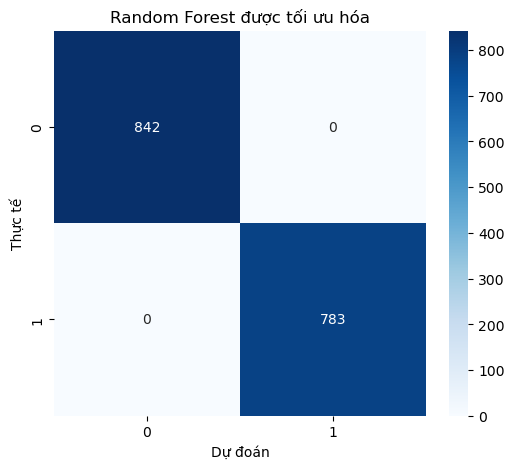

In [32]:
cm = confusion_matrix(
    y_test,
    pred_best
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title("Random Forest được tối ưu hóa")
plt.show()

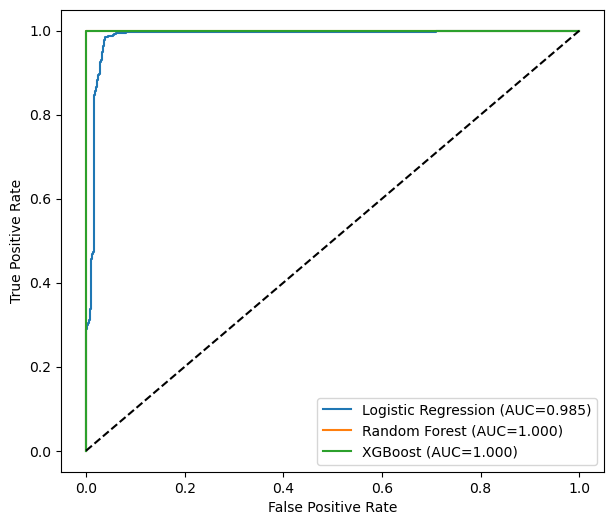

In [33]:
plt.figure(figsize=(7,6))
models = {
    "Logistic Regression":lr,
    "Random Forest":rf,
    "XGBoost":xgb
}
for name,model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test,prob)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr,tpr):.3f})"
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [34]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,odor,0.179867
8,gill_color,0.122870
7,gill_size,0.113607
19,spore_print_color,0.102116
18,ring_type,0.065316
20,population,0.061165
10,stalk_root,0.054003
11,stalk_surface_above_ring,0.050782
3,bruises,0.044802
21,habitat,0.033251


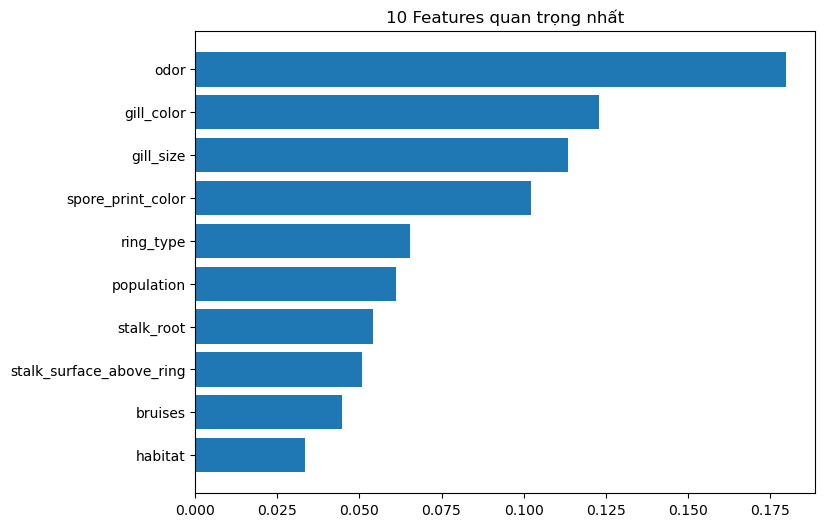

In [35]:
plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.title("10 Features quan trọng nhất")
plt.show()

In [36]:
joblib.dump(
    best_rf,
    "../models/best_model.pkl"
)
joblib.dump(
    encoders,
    "../models/encoders.pkl"
)
print("Lưu thành công.")

Lưu thành công.


In [37]:
import json
import sklearn
from datetime import datetime
import hashlib

with open("../data/agaricus-lepiota.data", "rb") as f:
    data_bytes = f.read()
data_version = hashlib.sha256(data_bytes).hexdigest()

model_version = "1.0.0"

metadata = {
    "model_version": model_version,
    "data_version": data_version,
    "model_type": type(best_rf).__name__,
    "model_params": best_rf.get_params(),
    "features": list(X.columns),
    "n_features": X.shape[1],
    "classes": list(encoders["poisonous"].classes_),
    "metrics": {
        "accuracy": accuracy_score(y_test, pred_best),
        "precision": precision_score(y_test, pred_best),
        "recall": recall_score(y_test, pred_best),
        "f1_score": f1_score(y_test, pred_best)
    },
    "sklearn_version": sklearn.__version__,
    "trained_at": datetime.now().isoformat()
}

with open("../models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Đã lưu model_metadata.json")
metadata



Đã lưu model_metadata.json


{'model_version': '1.0.0',
 'data_version': '346b29ee7911ea8c7fbd88b66e03a07c4d6ceaa77d7fa93cd1ea2ea96ea9965c',
 'model_type': 'RandomForestClassifier',
 'model_params': {'bootstrap': True,
  'ccp_alpha': 0.0,
  'class_weight': None,
  'criterion': 'gini',
  'max_depth': None,
  'max_features': 'sqrt',
  'max_leaf_nodes': None,
  'max_samples': None,
  'min_impurity_decrease': 0.0,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'min_weight_fraction_leaf': 0.0,
  'monotonic_cst': None,
  'n_estimators': 100,
  'n_jobs': None,
  'oob_score': False,
  'random_state': 42,
  'verbose': 0,
  'warm_start': False},
 'features': ['cap_shape',
  'cap_surface',
  'cap_color',
  'bruises',
  'odor',
  'gill_attachment',
  'gill_spacing',
  'gill_size',
  'gill_color',
  'stalk_shape',
  'stalk_root',
  'stalk_surface_above_ring',
  'stalk_surface_below_ring',
  'stalk_color_above_ring',
  'stalk_color_below_ring',
  'veil_type',
  'veil_color',
  'ring_number',
  'ring_type',
  'spore_print_

In [38]:
loaded_model = joblib.load("../models/best_model.pkl")
loaded_encoders = joblib.load("../models/encoders.pkl")

sample = X_test.iloc[[0]]
print("Model load lại dự đoán:", loaded_model.predict(sample))
print("Nhãn thật:", y_test.iloc[0])
print("Kiểm tra khớp model gốc:", (loaded_model.predict(X_test) == pred_best).all())
print(encoders["poisonous"].classes_)

Model load lại dự đoán: [1]
Nhãn thật: 1
Kiểm tra khớp model gốc: True
['e' 'p']
